# Exploration — France Electricity Forecasting

Dataset: `data/processed/dataset.parquet`, built by the ingestion pipeline (see `docs/decisions/0002-ingestion-pipeline-design.md`). Personal exploration notebook — see `docs/decisions/0003-exploratory-notebook-design.md` for scope and intent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/dataset.parquet")
df = df.set_index("date_heure").sort_index()
df.shape

(23252, 8)

## 1. Vue d'ensemble et qualité des données

In [2]:
print(f"Période : {df.index.min()} -> {df.index.max()}")
print(f"Nombre de lignes : {len(df)}")
print(f"Doublons d'index : {df.index.duplicated().sum()}")
print()
print("Taux de valeurs manquantes par colonne :")
print(df.isna().mean().sort_values(ascending=False))

Période : 2024-02-01 00:00:00+00:00 -> 2026-09-26 23:00:00+00:00
Nombre de lignes : 23252
Doublons d'index : 0

Taux de valeurs manquantes par colonne :
consommation             0.000344
prevision_j              0.000086
prevision_j1             0.000000
temperature_nationale    0.000000
est_ferie                0.000000
vacances_zone_a          0.000000
vacances_zone_b          0.000000
vacances_zone_c          0.000000
dtype: float64


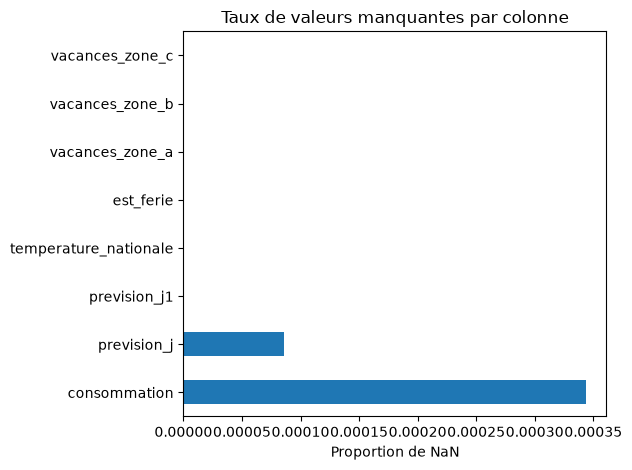

In [3]:
df.isna().mean().sort_values(ascending=False).plot.barh(
    title="Taux de valeurs manquantes par colonne"
)
plt.xlabel("Proportion de NaN")
plt.tight_layout()
plt.show()

Les valeurs manquantes actuelles sont concentrées à la toute fin du jeu de données (les heures les plus récentes, pas encore consolidées par RTE) — un phénomène différent, et permanent tant que le pipeline tourne, des trous historiques documentés dans `CLAUDE.md` (transitions DST, décalage de publication autour du 30 juin 2026).

## 2. Distribution et saisonnalité de la consommation

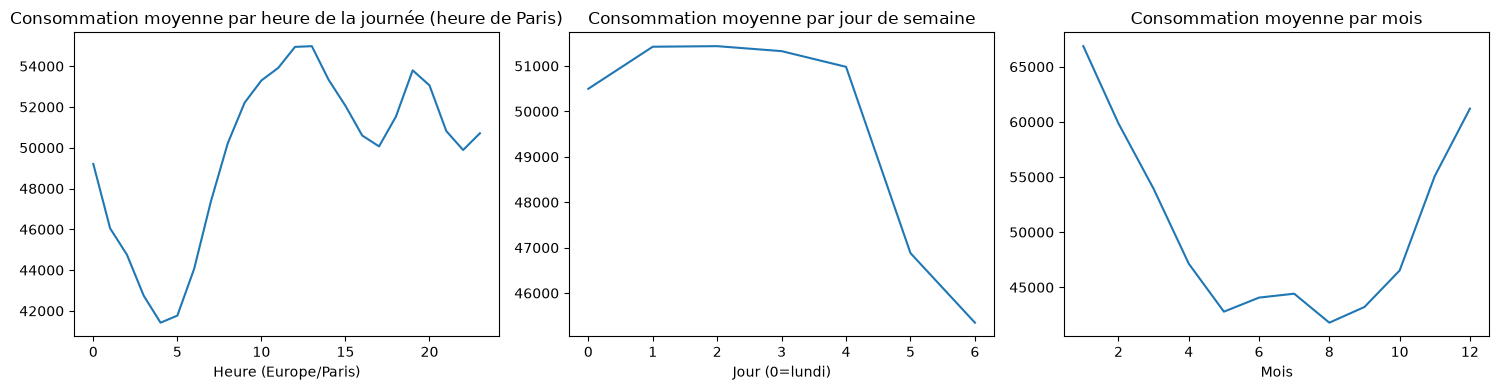

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

heure_locale = df.index.tz_convert("Europe/Paris").hour
df.groupby(heure_locale)["consommation"].mean().plot(
    ax=axes[0], title="Consommation moyenne par heure de la journée (heure de Paris)"
)
axes[0].set_xlabel("Heure (Europe/Paris)")

df.groupby(df.index.dayofweek)["consommation"].mean().plot(
    ax=axes[1], title="Consommation moyenne par jour de semaine"
)
axes[1].set_xlabel("Jour (0=lundi)")

df.groupby(df.index.month)["consommation"].mean().plot(
    ax=axes[2], title="Consommation moyenne par mois"
)
axes[2].set_xlabel("Mois")

plt.tight_layout()
plt.show()

## 3. Température vs consommation

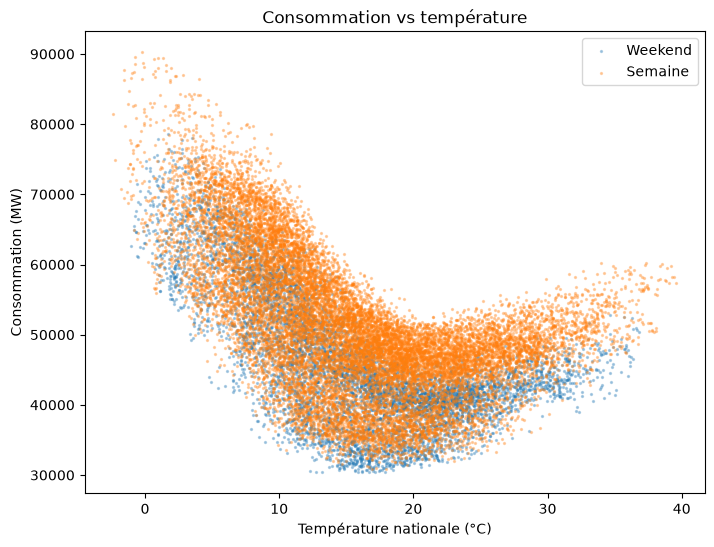

In [5]:
is_weekend = df.index.tz_convert("Europe/Paris").dayofweek >= 5

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df.loc[is_weekend, "temperature_nationale"],
    df.loc[is_weekend, "consommation"],
    s=2, alpha=0.3, label="Weekend",
)
ax.scatter(
    df.loc[~is_weekend, "temperature_nationale"],
    df.loc[~is_weekend, "consommation"],
    s=2, alpha=0.3, label="Semaine",
)
ax.set_xlabel("Température nationale (°C)")
ax.set_ylabel("Consommation (MW)")
ax.legend()
ax.set_title("Consommation vs température")
plt.show()

## 4. Effet jours fériés et vacances scolaires

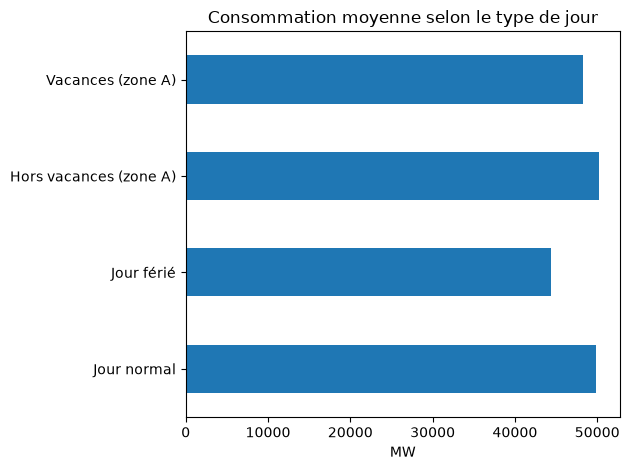

Jour normal               49864.678286
Jour férié                44377.686422
Hors vacances (zone A)    50254.637925
Vacances (zone A)         48228.345352
dtype: float64

In [6]:
comparison = pd.Series({
    "Jour normal": df.loc[~df["est_ferie"], "consommation"].mean(),
    "Jour férié": df.loc[df["est_ferie"], "consommation"].mean(),
    "Hors vacances (zone A)": df.loc[~df["vacances_zone_a"], "consommation"].mean(),
    "Vacances (zone A)": df.loc[df["vacances_zone_a"], "consommation"].mean(),
})

comparison.plot.barh(title="Consommation moyenne selon le type de jour")
plt.xlabel("MW")
plt.tight_layout()
plt.show()
comparison

Limites à garder en tête sur ces deux chiffres :

- **Ce ne sont pas deux effets indépendants et additifs.** 52% des heures fériées tombent aussi pendant les vacances de zone A. En séparant les deux : un jour férié *hors* vacances fait chuter la consommation de ~17,6%, contre seulement ~2,7% pour un jour férié qui tombe *pendant* les vacances (l'effet vacances "mange" déjà une bonne partie de la baisse). Le -11% affiché est un mélange des deux, pas un effet propre.
- **L'échantillon férié est petit** : 29 jours distincts (696 heures) contre ~265 jours (6 358 heures) pour les vacances — un ordre de grandeur d'écart. Le -11% est donc une estimation moins solide que le -4%.
- **Seule la zone A est regardée ici.** Environ 8% des heures classées "hors vacances" sont en réalité des vacances pour les zones B ou C, ce qui tire légèrement le -4% vers zéro (~5-6% de l'effet lui-même). À creuser si ces variables servent vraiment de features au modèle.

## 5. Erreur de la prévision RTE (prevision_j1) — le niveau à atteindre

In [7]:
errors = df["prevision_j1"] - df["consommation"]
mae = errors.abs().mean()
mape = (errors.abs() / df["consommation"]).mean() * 100
bias = errors.mean()

print(f"MAE (prevision_j1 vs réel) : {mae:.0f} MW")
print(f"MAPE (prevision_j1 vs réel) : {mape:.2f} %")
print(f"Biais moyen signé (prevision_j1 - réel) : {bias:.0f} MW")

MAE (prevision_j1 vs réel) : 1349 MW
MAPE (prevision_j1 vs réel) : 2.73 %
Biais moyen signé (prevision_j1 - réel) : -967 MW


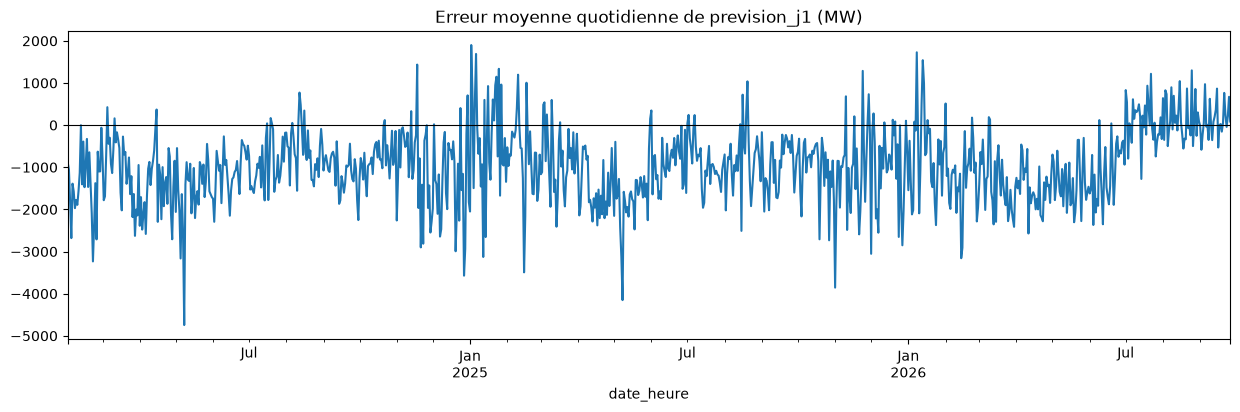

In [8]:
errors.resample("D").mean().plot(
    figsize=(15, 4), title="Erreur moyenne quotidienne de prevision_j1 (MW)"
)
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

RTE ne se trompe pas au hasard : son biais est **systématiquement négatif** (elle sous-estime la consommation réelle sur ~88% des jours). Plus intéressant : ce biais n'est pas stable dans le temps. En regroupant par trimestre, il reste constant, avec des fluctuations trimestrielles, entre -600 et -1 400 MW pendant 10 trimestres (2024 T1 → 2026 T2), puis bascule à environ +121 MW au dernier trimestre (2026 T3) — le seul trimestre positif de toute la série. À creuser avant de considérer -967 MW comme un biais stable : est-ce un vrai changement de méthode côté RTE, ou un artefact des données les plus récentes pas encore consolidées (voir la remarque de la section 1) ?